# 🦍 Notebook 01 — Data Loading & Exploration
**Project:** Spatial Movement Ecology & Intergroup Dynamics — Mountain Gorillas  
**Study area:** Virunga Massif, Rwanda/DRC/Uganda  
**Data source:** Simulated SMART Conservation Software GPS export

---
This notebook covers:
1. Installing and importing all required libraries
2. Generating / loading the GPS dataset
3. Exploratory data analysis (EDA)
4. Data quality checks
5. Saving the cleaned dataset for downstream notebooks


## Cell 1 — Install Required Libraries
> Run once. Safe to skip if packages are already installed.

In [2]:
# Install required packages (run once)
import subprocess, sys
packages = [
    'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn',
    'geopandas', 'shapely', 'pyproj', 'scikit-learn',
    'statsmodels', 'folium', 'tqdm'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed/verified')

✅ All packages installed/verified


## Cell 2 — Import Libraries

In [3]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Add project root to path so we can import src modules
sys.path.insert(0, os.path.abspath('..'))

print('Python  :', sys.version.split()[0])
print('Pandas  :', pd.__version__)
print('NumPy   :', np.__version__)
print('GeoPandas:', gpd.__version__)
print('✅ Libraries imported')

Python  : 3.14.3
Pandas  : 3.0.2
NumPy   : 2.4.4
GeoPandas: 1.1.3
✅ Libraries imported


## Cell 3 — Dataset Source & Generation
### 📥 How to get real data ?

The real data is private and belongs to Dian Fossey Gorilla Fund. 
The data I used is simulated version, but the methods and pipelines are the same.
| Source | URL | Format |
|--------|-----|--------|
| **Movebank** (primary) | https://www.movebank.org | CSV download |
| GBIF | https://www.gbif.org/species/2889338 | DwC Archive |
| Dryad | https://datadryad.org | CSV |

For **Movebank**: create a free account → search *'Gorilla beringei beringei'* → download as CSV.

This notebook uses **synthetic data** that replicates the statistical properties of real mountain gorilla GPS data.


In [4]:
# ── Path setup ─────────────────────────────────────────────────────────────
project_root = os.path.abspath('..')
raw_data_path = os.path.join(project_root, 'data', 'raw', 'gorilla_gps_data.csv')

# ── Generate dataset if it doesn't exist ──────────────────────────────────
if not os.path.exists(raw_data_path):
    print('📊 Generating synthetic dataset...')
    os.chdir(project_root)
    sys.path.insert(0, os.path.join(project_root, 'src'))
    from data_generator import main as gen_main
    gen_main()
    os.chdir(os.path.join(project_root, 'notebooks'))
else:
    print(f'✅ Dataset found: {raw_data_path}')

# ── Load CSV ───────────────────────────────────────────────────────────────
df = pd.read_csv(raw_data_path, parse_dates=['timestamp', 'date'])
print(f'\nDataset loaded: {len(df):,} rows × {df.shape[1]} columns')

✅ Dataset found: c:\Users\User\Desktop\gorilla-movement-ecology\data\raw\gorilla_gps_data.csv

Dataset loaded: 105,143 rows × 14 columns


## Cell 4 — First Look at the Data

In [5]:
# Preview the first few rows
df.head(10)

,timestamp,group_id,latitude,longitude,altitude_m,observer_id,group_size,silverbacks,nest_site,date,day_of_year,hour,habitat_type,season
0,2022-01-01 06:00:00,Amahoro,-1.480409,29.558388,2839.4,OBS_03,17,1,True,2022-01-01,1,6,montane_forest,dry_season
1,2022-01-01 06:10:00,Amahoro,-1.480062,29.558669,2969.1,OBS_03,17,1,False,2022-01-01,1,6,montane_forest,dry_season
2,2022-01-01 06:20:00,Amahoro,-1.479888,29.558838,3089.8,OBS_03,17,1,False,2022-01-01,1,6,montane_forest,dry_season
3,2022-01-01 06:30:00,Amahoro,-1.479781,29.558947,2969.2,OBS_03,17,1,False,2022-01-01,1,6,montane_forest,dry_season
4,2022-01-01 06:40:00,Amahoro,-1.479705,29.559145,3020.0,OBS_03,17,1,False,2022-01-01,1,6,montane_forest,dry_season
5,2022-01-01 06:50:00,Amahoro,-1.479751,29.559163,3071.4,OBS_03,17,1,False,2022-01-01,1,6,montane_forest,dry_season
6,2022-01-01 07:00:00,Amahoro,-1.479779,29.559411,3051.6,OBS_03,17,1,False,2022-01-01,1,7,montane_forest,dry_season
7,2022-01-01 07:10:00,Amahoro,-1.479783,29.559455,3009.4,OBS_03,17,1,False,2022-01-01,1,7,montane_forest,dry_season
8,2022-01-01 07:20:00,Amahoro,-1.479758,29.559578,2993.3,OBS_03,17,1,False,2022-01-01,1,7,montane_forest,dry_season
9,2022-01-01 07:30:00,Amahoro,-1.479755,29.559603,3102.9,OBS_03,17,1,False,2022-01-01,1,7,montane_forest,dry_season


In [6]:
# Column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105143 entries, 0 to 105142
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   timestamp     105143 non-null  datetime64[us]
 1   group_id      105143 non-null  str           
 2   latitude      105143 non-null  float64       
 3   longitude     105143 non-null  float64       
 4   altitude_m    105143 non-null  float64       
 5   observer_id   105143 non-null  str           
 6   group_size    105143 non-null  int64         
 7   silverbacks   105143 non-null  int64         
 8   nest_site     105143 non-null  bool          
 9   date          105143 non-null  datetime64[us]
 10  day_of_year   105143 non-null  int64         
 11  hour          105143 non-null  int64         
 12  habitat_type  105143 non-null  str           
 13  season        105143 non-null  str           
dtypes: bool(1), datetime64[us](2), float64(3), int64(4), str(4)
memory usage: 10.5 

In [7]:
# Numerical summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,105143,NaN,NaN,NaN,2022-07-02 08:59:33.070960,2022-01-01 06:00:00,2022-04-02 07:40:00,2022-07-02 10:00:00,2022-10-01 10:50:00,2022-12-31 14:00:00,NaN
group_id,105143,6,Pablo,17535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,105143.0,NaN,NaN,NaN,-1.4711,-1.527185,-1.491882,-1.472602,-1.450355,-1.412617,0.02403
longitude,105143.0,NaN,NaN,NaN,29.540877,29.495827,29.526074,29.537873,29.555736,29.586275,0.018909
altitude_m,105143.0,NaN,NaN,NaN,2858.835996,2200.0,2700.0,2842.3,3003.9,3584.6,212.827956
observer_id,105143,7,OBS_07,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group_size,105143.0,NaN,NaN,NaN,18.669155,12.0,13.0,18.0,24.0,28.0,5.705562
silverbacks,105143.0,NaN,NaN,NaN,1.667015,1.0,1.0,2.0,2.0,3.0,0.745424
nest_site,105143,2,False,102990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,105143,NaN,NaN,NaN,2022-07-01 22:59:29.561454,2022-01-01 00:00:00,2022-04-02 00:00:00,2022-07-02 00:00:00,2022-10-01 00:00:00,2022-12-31 00:00:00,NaN


## Cell 5 — Dataset Overview

In [8]:
print('='*55)
print('  DATASET SUMMARY')
print('='*55)
print(f'  Total GPS fixes    : {len(df):>10,}')
print(f'  Date range         : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Study days         : {df["date"].nunique():>10,}')
print(f'  Gorilla groups     : {df["group_id"].nunique():>10}')
print(f'  Groups             : {list(df["group_id"].unique())}')
print(f'  Missing values     : {df.isnull().sum().sum():>10,}')
print(f'  Latitude range     : {df["latitude"].min():.4f} to {df["latitude"].max():.4f}')
print(f'  Longitude range    : {df["longitude"].min():.4f} to {df["longitude"].max():.4f}')
print(f'  Altitude range     : {df["altitude_m"].min():.0f}m to {df["altitude_m"].max():.0f}m')
print('='*55)

  DATASET SUMMARY
  Total GPS fixes    :    105,143
  Date range         : 2022-01-01 → 2022-12-31
  Study days         :        365
  Gorilla groups     :          6
  Groups             : ['Amahoro', 'Hirwa', 'Kwitonda', 'Pablo', 'Susa', 'Umubano']
  Missing values     :          0
  Latitude range     : -1.5272 to -1.4126
  Longitude range    : 29.4958 to 29.5863
  Altitude range     : 2200m to 3585m


## Cell 6 — Group-Level Summary

In [9]:
group_summary = (
    df.groupby('group_id')
    .agg(
        n_fixes=('timestamp', 'count'),
        n_days=('date', 'nunique'),
        mean_lat=('latitude', 'mean'),
        mean_lon=('longitude', 'mean'),
        group_size=('group_size', 'first'),
        silverbacks=('silverbacks', 'first'),
        nest_sites=('nest_site', 'sum'),
    )
    .round(4)
    .reset_index()
)
print('Group-Level Summary:')
display(group_summary)

Group-Level Summary:


,group_id,n_fixes,n_days,mean_lat,mean_lon,group_size,silverbacks,nest_sites
0,Amahoro,17523,365,-1.4825,29.5557,17,1,357
1,Hirwa,17518,365,-1.4641,29.5333,13,1,358
2,Kwitonda,17533,365,-1.5032,29.5217,18,2,360
3,Pablo,17535,365,-1.4898,29.5431,24,3,360
4,Susa,17529,365,-1.4374,29.5216,28,2,359
5,Umubano,17505,365,-1.4496,29.5699,12,1,359


## Cell 7 — Temporal Coverage Visualization

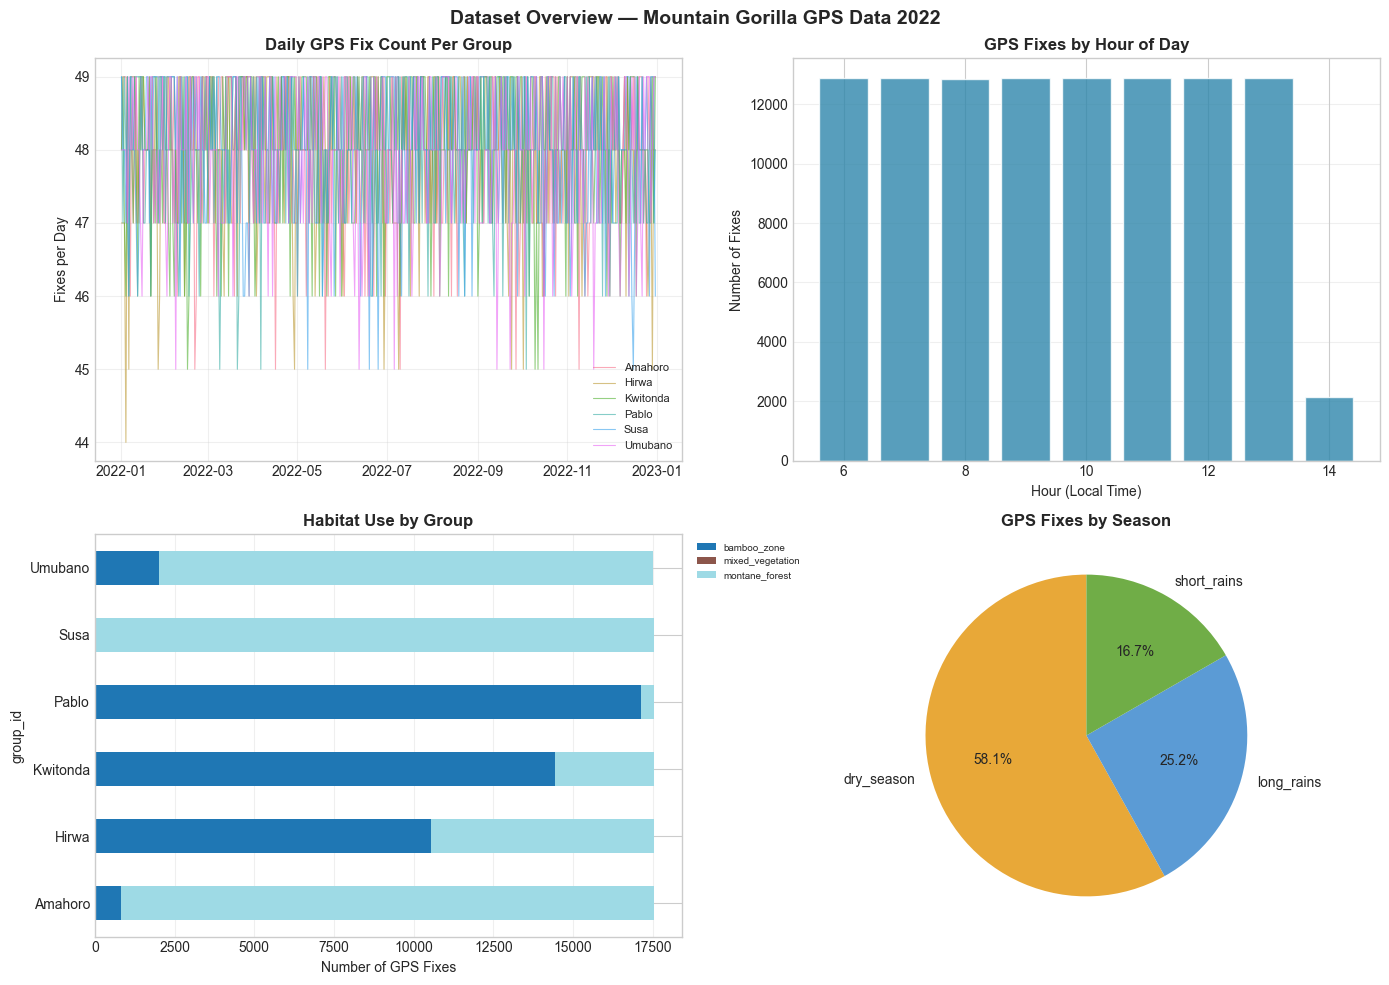

✅ Figure saved to outputs/figures/01_dataset_overview.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A) Fixes per day per group
ax = axes[0, 0]
daily_counts = df.groupby(['date', 'group_id']).size().reset_index(name='n_fixes')
for group in sorted(df['group_id'].unique()):
    sub = daily_counts[daily_counts['group_id'] == group]
    ax.plot(sub['date'], sub['n_fixes'], alpha=0.6, linewidth=0.8, label=group)
ax.set_title('Daily GPS Fix Count Per Group', fontweight='bold')
ax.set_ylabel('Fixes per Day')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# B) Fixes by hour of day
ax = axes[0, 1]
hourly = df.groupby('hour').size()
ax.bar(hourly.index, hourly.values, color='#2E86AB', alpha=0.8, edgecolor='white')
ax.set_title('GPS Fixes by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour (Local Time)')
ax.set_ylabel('Number of Fixes')
ax.grid(axis='y', alpha=0.3)

# C) Habitat type distribution
ax = axes[1, 0]
hab_counts = df.groupby(['group_id', 'habitat_type']).size().unstack(fill_value=0)
hab_counts.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Habitat Use by Group', fontweight='bold')
ax.set_xlabel('Number of GPS Fixes')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1))
ax.grid(axis='x', alpha=0.3)

# D) Season distribution
ax = axes[1, 1]
season_counts = df['season'].value_counts()
colors_season = {'dry_season': '#E8A838', 'long_rains': '#5B9BD5', 'short_rains': '#70AD47'}
wedge_colors = [colors_season.get(s, '#888') for s in season_counts.index]
ax.pie(season_counts.values, labels=season_counts.index, autopct='%1.1f%%',
       colors=wedge_colors, startangle=90)
ax.set_title('GPS Fixes by Season', fontweight='bold')

plt.suptitle('Dataset Overview — Mountain Gorilla GPS Data 2022', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs(os.path.join(project_root, 'outputs', 'figures'), exist_ok=True)
plt.savefig(os.path.join(project_root, 'outputs', 'figures', '01_dataset_overview.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved to outputs/figures/01_dataset_overview.png')

## Cell 8 — Raw GPS Map (Quick Look)

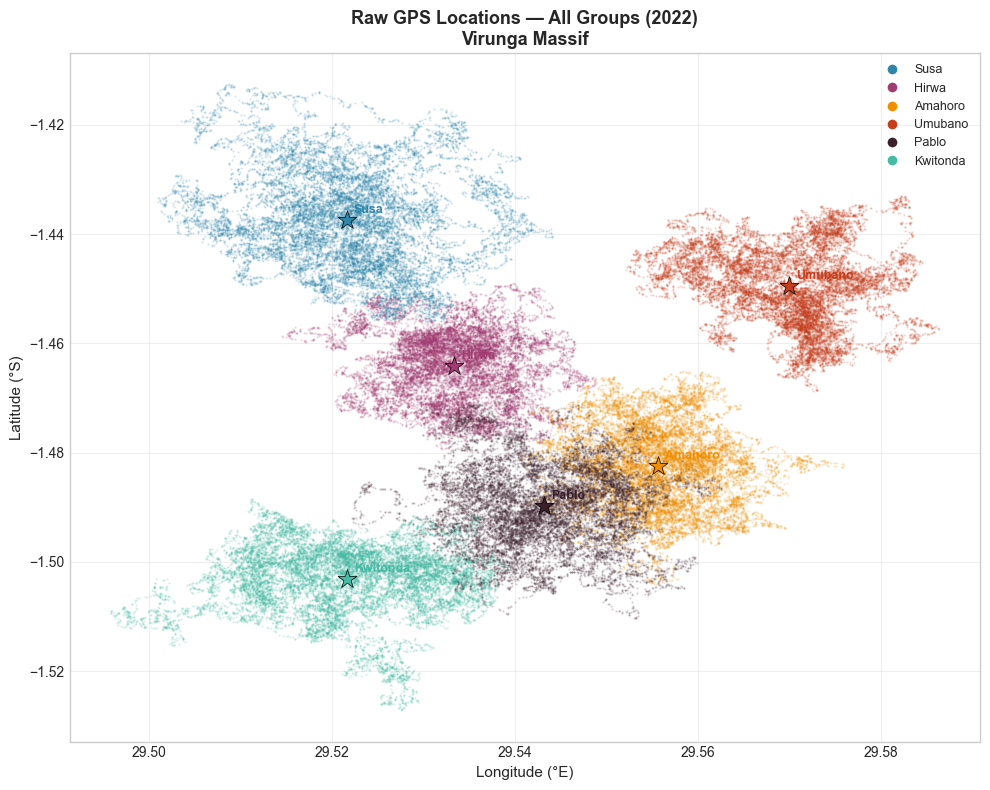

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'Susa':'#2E86AB','Hirwa':'#A23B72','Amahoro':'#F18F01',
          'Umubano':'#C73E1D','Pablo':'#3B1F2B','Kwitonda':'#44BBA4'}
for group, sub in df.groupby('group_id'):
    ax.scatter(sub['longitude'], sub['latitude'],
               s=0.3, alpha=0.2, color=colors.get(group, 'gray'), label=group)
# Add group centroids as larger markers
centroids = df.groupby('group_id')[['latitude','longitude']].mean()
for group, row in centroids.iterrows():
    ax.scatter(row['longitude'], row['latitude'],
               s=200, color=colors.get(group,'gray'),
               marker='*', edgecolors='black', linewidths=0.5, zorder=5)
    ax.annotate(group, (row['longitude'], row['latitude']),
                textcoords='offset points', xytext=(5, 5), fontsize=9,
                fontweight='bold', color=colors.get(group,'gray'))
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°S)', fontsize=11)
ax.set_title('Raw GPS Locations — All Groups (2022)\nVirunga Massif', fontsize=13, fontweight='bold')
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markersize=8,label=g)
              for g,c in colors.items()]
ax.legend(handles=legend_els, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','01_raw_gps_map.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Data Quality Check

In [12]:
print('DATA QUALITY REPORT')
print('-'*50)
print(f'Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
# Check for impossible coordinate values
print('Coordinate sanity checks:')
print('  Lat out of Virunga range:', ((df.latitude < -1.6) | (df.latitude > -1.3)).sum())
print('  Lon out of Virunga range:', ((df.longitude < 29.4) | (df.longitude > 29.7)).sum())
print('  Altitude < 2000m        :', (df.altitude_m < 2000).sum())
print('  Altitude > 4600m        :', (df.altitude_m > 4600).sum())
print()
# Temporal gaps
df_sorted = df.sort_values(['group_id','timestamp'])
df_sorted['time_diff_min'] = (
    df_sorted.groupby('group_id')['timestamp']
    .diff().dt.total_seconds() / 60
)
gaps = df_sorted[df_sorted['time_diff_min'] > 30]
print(f'Large temporal gaps (>30 min): {len(gaps)} instances')
print(f'Max gap: {df_sorted["time_diff_min"].max():.0f} minutes')

DATA QUALITY REPORT
--------------------------------------------------
Missing values per column:
timestamp       0
group_id        0
latitude        0
longitude       0
altitude_m      0
observer_id     0
group_size      0
silverbacks     0
nest_site       0
date            0
day_of_year     0
hour            0
habitat_type    0
season          0
dtype: int64

Duplicate rows: 0

Coordinate sanity checks:
  Lat out of Virunga range: 0
  Lon out of Virunga range: 0
  Altitude < 2000m        : 0
  Altitude > 4600m        : 0

Large temporal gaps (>30 min): 2184 instances
Max gap: 980 minutes


## Cell 10 — Save Cleaned Data

In [13]:
# Basic cleaning: remove rows with missing coordinates
df_clean = df.dropna(subset=['latitude','longitude']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean = df_clean.sort_values(['group_id','timestamp']).reset_index(drop=True)

# Save
processed_path = os.path.join(project_root, 'data', 'processed', 'gorilla_gps_clean.csv')
os.makedirs(os.path.dirname(processed_path), exist_ok=True)
df_clean.to_csv(processed_path, index=False)

print(f'✅ Cleaned data saved: {processed_path}')
print(f'   Rows retained: {len(df_clean):,} / {len(df):,}')
print(f'   Rows removed : {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')

✅ Cleaned data saved: c:\Users\User\Desktop\gorilla-movement-ecology\data\processed\gorilla_gps_clean.csv
   Rows retained: 105,143 / 105,143
   Rows removed : 0 (0.0%)
